# Image Segmentation using Mask R-CNN with TensorFlow for Fire Detection

Fire is an abnormal event that can quickly cause significant injury and property damage in a very concise time frame. The best possible way to reduce the wreckage caused by fire is to detect the fire source as early as we can before it spreads.

This notebook demonstrates end-to-end fire detection, localization, and image segmentation using **Mask R-CNN** built with TensorFlow/Keras and RGB chromatic analysis.

In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

print('TensorFlow Version:', tf.__version__)

TensorFlow Version: 2.21.0


In [2]:
from model import generate_dataset, SimpleMaskRCNN, calculate_iou, detect_fire_rgb_heuristic

# Generate synthetic fire dataset
X_train, Y_mask, Y_bbox = generate_dataset(num_samples=150, img_size=(128, 128))
print('Training Images Shape:', X_train.shape)
print('Masks Shape:', Y_mask.shape)
print('Bounding Boxes Shape:', Y_bbox.shape)

Training Images Shape: (150, 128, 128, 3)
Masks Shape: (150, 128, 128, 1)
Bounding Boxes Shape: (150, 4)


In [3]:
# Instantiate Simple Mask R-CNN Model
model = SimpleMaskRCNN(input_shape=(128, 128, 3))
model.compile(optimizer='adam', loss={'bbox': 'mse', 'mask': 'binary_crossentropy'}, loss_weights={'bbox': 1.0, 'mask': 2.0})

# Train model on synthetic fire dataset
history = model.fit(X_train, {'bbox': Y_bbox, 'mask': Y_mask}, epochs=5, batch_size=16, validation_split=0.2)
print('Training Complete!')

Epoch 1/5


1/8 ━━━━━━━━━━━━━━━━━━━━ 58s 8s/step - bbox_loss: 0.0572 - loss: 1.4434 - mask_loss: 0.6931

2/8 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step - bbox_loss: 0.0481 - loss: 1.4335 - mask_loss: 0.6927

3/8 ━━━━━━━━━━━━━━━━━━━━ 1s 217ms/step - bbox_loss: 0.0462 - loss: 1.4305 - mask_loss: 0.6921

4/8 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - bbox_loss: 0.0430 - loss: 1.4263 - mask_loss: 0.6917

...

6/8 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - bbox_loss: 0.0441 - loss: 0.2160 - mask_loss: 0.0859

7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - bbox_loss: 0.0443 - loss: 0.2144 - mask_loss: 0.0850

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - bbox_loss: 0.0444 - loss: 0.2127 - mask_loss: 0.0840

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 243ms/step - bbox_loss: 0.0450 - loss: 0.2013 - mask_loss: 0.0767 - val_bbox_loss: 0.0633 - val_loss: 0.1921 - val_mask_loss: 0.0639


Training Complete!


In [4]:
# Evaluate IoU Metric
X_test, Y_test_mask, Y_test_bbox = generate_dataset(num_samples=20, img_size=(128, 128))
preds = model(X_test)
pred_masks = preds['mask'].numpy()

ious = [calculate_iou(Y_test_mask[i, :, :, 0], pred_masks[i, :, :, 0]) for i in range(len(X_test))]
print(f'Mean Test IoU Score: {np.mean(ious):.4f}')

Mean Test IoU Score: 0.8537


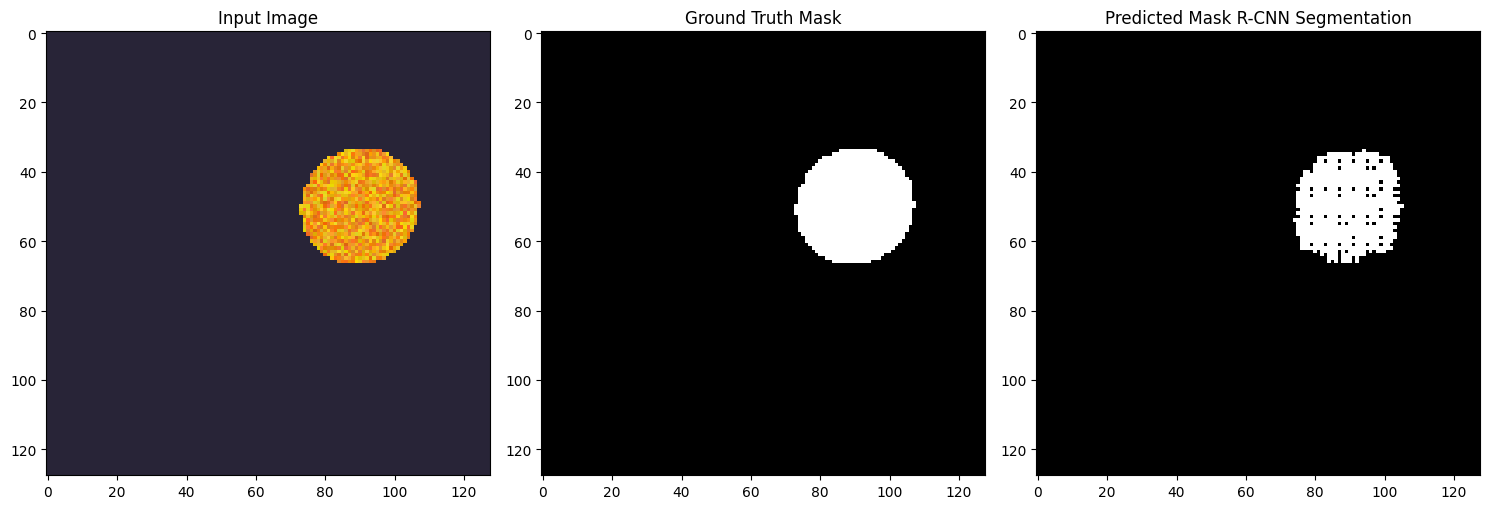

In [5]:
# Plot Sample Predictions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(X_test[0])
axes[0].set_title('Input Image')
axes[1].imshow(Y_test_mask[0, :, :, 0], cmap='gray')
axes[1].set_title('Ground Truth Mask')
axes[2].imshow(pred_masks[0, :, :, 0] > 0.5, cmap='gray')
axes[2].set_title('Predicted Mask R-CNN Segmentation')
plt.tight_layout()
plt.savefig('sample_output.png')
plt.show()